In [1]:
import numpy as np
import pandas as pd
from typing import Any, List
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

### Original version of the FCA classifier (Provided by Mr. A. Tomat)

In [ ]:
class LazyClassifierFCA:
    def __init__(self):
        self.X_train = None
        self.y_train = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series) -> None:
        self.X_train = X_train
        self.y_train = y_train
        
    def classify_sample(self, sample: pd.Series) -> Any:
        # Split X_train into positive and negative classes
        X_train_positive = self.X_train[y_train == 1]
        X_train_negative = self.X_train[y_train == 0]
        
        positive_classifiers = 0
        negative_classifiers = 0

        # Split the each part into binary and numerical
        binary_X_train_positive = X_train_positive.select_dtypes(include='bool')
        numerical_X_train_positive = X_train_positive.select_dtypes(exclude='bool')
        binary_X_train_negative = X_train_negative.select_dtypes(include='bool')
        numerical_X_train_negative = X_train_negative.select_dtypes(exclude='bool')
        
        
        def find_number_of_positive_and_negative_matches(binary_intersection, numerical_intervals):
            # Binary condition: Matches the binary intersection
            binary_positive_match = (binary_X_train_positive | ~binary_intersection).all(axis=1)
            binary_negative_match = (binary_X_train_negative | ~binary_intersection).all(axis=1)
    
            # Numerical condition: Lies within the intervals
            numerical_positive_match = numerical_X_train_positive.apply(
                lambda row: all(
                    interval[0] <= value <= interval[1] for value, interval in zip(row, numerical_intervals)
                ),
                axis=1
            )
            numerical_negative_match = numerical_X_train_negative.apply(
                lambda row: all(
                    interval[0] <= value <= interval[1] for value, interval in zip(row, numerical_intervals)
                ),
                axis=1
            )
            # print(f"pos_supp: \n {list(X_train_positive[(binary_positive_match & numerical_positive_match)].index)}")
            # print(f"neg_supp: \n {list(X_train_negative[(binary_negative_match & numerical_negative_match)].index)}")
            # Combine binary and numerical conditions
            num_positive = (binary_positive_match & numerical_positive_match).sum()
            num_negative = (binary_negative_match & numerical_negative_match).sum()
            return num_positive, num_negative
        
        # Function to check if intersection with a train sample is a positive classifier
        def is_positive_classifier(binary_intersection, numerical_intervals):
            num_positive, num_negative = find_number_of_positive_and_negative_matches(binary_intersection, numerical_intervals)
            return num_negative == 0 and num_positive > 1
        
        # Function to check if intersection is a negative classifier
        def is_negative_classifier(binary_intersection, numerical_intervals):
            num_positive, num_negative = find_number_of_positive_and_negative_matches(binary_intersection, numerical_intervals)
            return num_positive == 0 and num_negative > 1
        
        # Check for positive classifiers by intersecting sample with each positive object
        for _, pos_sample in X_train_positive.iterrows():
            # Binary intersection: AND operation
            binary_intersection = sample[binary_X_train_positive.columns] & pos_sample[binary_X_train_positive.columns]
            
            # Numerical intersection: Interval
            numerical_intersection = [
                (min(sample[col], pos_sample[col]), max(sample[col], pos_sample[col]))
                for col in numerical_X_train_positive.columns
            ]
            # print({sample.name}, {pos_sample.name})
            # print(f"{sample=}")
            # print(f"{pos_sample=}")
            # print(f"{binary_intersection=} \n {numerical_intersection=}")
            
            # Combine intersections and check
            if is_positive_classifier(binary_intersection, numerical_intersection):
                positive_classifiers += 1
        
        # Check for negative classifiers by intersecting sample with each negative object
        for _, neg_sample in X_train_negative.iterrows():
            # Binary intersection: AND operation
            binary_intersection = sample[binary_X_train_negative.columns] & neg_sample[binary_X_train_negative.columns]
            
            # Numerical intersection: Interval
            numerical_intersection = [
                (min(sample[col], neg_sample[col]), max(sample[col], neg_sample[col]))
                for col in numerical_X_train_negative.columns
            ]
            
            # Combine intersections and check
            if is_negative_classifier(binary_intersection, numerical_intersection):
                negative_classifiers += 1

        # Determine the class based on the number of classifiers
        if positive_classifiers > negative_classifiers:
            print(f"sample {sample.name} is classified as 1, {positive_classifiers=}, {negative_classifiers=}")
            return 1  # Predict positive
            
        elif negative_classifiers > positive_classifiers:
            print(f"sample {sample.name} is classified as 0, {positive_classifiers=}, {negative_classifiers=}")
            return 0  # Predict negative

        else:
            # If equal, you can decide on a rule, like defaulting to 0 or 1, or returning 'undetermined'
            print(f"sample {sample.name} is classified as 1, default, {positive_classifiers=}, {negative_classifiers=}")
        
            return 1  # or 0, depending on the choice


    def predict(self, X_test: pd.DataFrame) -> List[Any]:
        # List to store predictions for each test sample
        predictions = []
        
        # Iterate through each sample in X_test
        for _, sample in X_test.iterrows():
            # Classify the sample and append the result to predictions
            prediction = self.classify_sample(sample)
            predictions.append(prediction)
        
        return predictions

In [2]:
data = pd.read_csv('data/cleaned_encoded_data.csv', index_col = False)

In [3]:
data['Education'] = data['Education'].map({'Bachelors': 1, 'Masters': 2, 'PHD': 3})

In [4]:
data=data.drop(columns=["ExperienceInCurrentDomain","PaymentTier_intervals", "Age_intervals","ExperienceInCurrentDomain_intervals","Age","Education","PaymentTier","JoiningYear","JoiningYear_intervals","Education_intervals"])

In [5]:
data

,LeaveOrNot,city_is_bangalore,city_is_pune,city_is_new_delhi,gender_is_male,gender_is_female,is_ever_benched,is_never_benched,Education_categories,JoiningYear_categories,PaymentTier_categories,Age_categories,ExperienceInCurrentDomain_categories
0,0,1,0,0,1,0,0,1,1,5,3,12,0
1,1,0,1,0,0,1,0,1,1,1,1,6,3
2,0,0,0,1,0,1,0,1,1,2,3,16,2
3,1,1,0,0,1,0,0,1,2,4,3,5,5
4,1,0,1,0,1,0,1,0,2,5,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3321,0,1,0,0,0,1,0,1,1,1,3,4,4
3322,1,0,1,0,1,0,0,1,2,1,2,15,2
3323,1,0,0,1,1,0,0,1,2,6,3,5,5
3324,0,1,0,0,1,0,1,0,1,0,3,8,2


In [6]:
def to_bool_series(s, true_values=None):
    if true_values is None:
        true_values = {'yes','y','true','t','1','male','m', True, 1}
    return s.fillna('').astype(str).str.strip().str.lower().isin({str(v).lower() for v in true_values})

data['city_is_bangalore'] = to_bool_series(data['city_is_bangalore'], true_values={'1',1})
data['city_is_pune'] = to_bool_series(data['city_is_pune'], true_values={'1',1})
data['city_is_new_delhi'] = to_bool_series(data['city_is_new_delhi'], true_values={'1',1})
data['gender_is_male'] = to_bool_series(data['gender_is_male'], true_values={'1',1})
data['gender_is_female'] = to_bool_series(data['gender_is_female'], true_values={'1',1})
data['is_ever_benched'] = to_bool_series(data['is_ever_benched'], true_values={'1',1})
data['is_never_benched'] = to_bool_series(data['is_never_benched'], true_values={'1',1})

In [7]:
data

,LeaveOrNot,city_is_bangalore,city_is_pune,city_is_new_delhi,gender_is_male,gender_is_female,is_ever_benched,is_never_benched,Education_categories,JoiningYear_categories,PaymentTier_categories,Age_categories,ExperienceInCurrentDomain_categories
0,0,True,False,False,True,False,False,True,1,5,3,12,0
1,1,False,True,False,False,True,False,True,1,1,1,6,3
2,0,False,False,True,False,True,False,True,1,2,3,16,2
3,1,True,False,False,True,False,False,True,2,4,3,5,5
4,1,False,True,False,True,False,True,False,2,5,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3321,0,True,False,False,False,True,False,True,1,1,3,4,4
3322,1,False,True,False,True,False,False,True,2,1,2,15,2
3323,1,False,False,True,True,False,False,True,2,6,3,5,5
3324,0,True,False,False,True,False,True,False,1,0,3,8,2


In [8]:
y = data.LeaveOrNot
X = data.drop(columns = 'LeaveOrNot')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [9]:
from classifiers.executor import FastClassifierFCAParallel

In [10]:
classifier = FastClassifierFCAParallel()
# This call now performs necessary data preprocessing just once
classifier.fit(X_train, y_train)

In [ ]:
if __name__ == '__main__':
    # Эта часть кода будет выполнена только в главном процессе
    
    # Предполагается, что 'classifier', 'X_test', 'y_test' определены ранее
    
    print("Initializing concurrent processing...")
    y_pred_fast = classifier.predict(X_test, n_jobs=-1) 
    
    print("Classification report:")
    print(classification_report(y_test, y_pred_fast))

Запуск параллельного предсказания...
11
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       425
           1       0.94      0.77      0.84       241

    accuracy                           0.90       666
   macro avg       0.91      0.87      0.88       666
weighted avg       0.90      0.90      0.90       666



Let's try to calculate importance of features

In [ ]:
if __name__ == '__main__':
    
    print("Initializing concurrent processing...")
    importance_results = classifier.calculate_frequency_importance(X_test, n_jobs=-1) 
    
    print("Computations are finished.")
    print("\nMost important features for positive classifiers (Top-5):")
    print(importance_results['positive'].head())

    print("\nMost important features for negative classifiers (Top-5):")
    print(importance_results['negative'].head())

Начало параллельного подсчета важности признаков...
Общее количество найденных чистых POSITIVE правил: 63188
Общее количество найденных чистых NEGATIVE правил: 142915
Подсчет завершен.

Важность для Положительного класса (Топ-5):
                                      Feature Importance (Pos)
Education_categories                                       1.0
JoiningYear_categories                                     1.0
PaymentTier_categories                                     1.0
Age_categories                                             1.0
ExperienceInCurrentDomain_categories                       1.0

Важность для Отрицательного класса (Топ-5):
                                      Feature Importance (Neg)
Education_categories                                       1.0
JoiningYear_categories                                     1.0
PaymentTier_categories                                     1.0
Age_categories                                             1.0
ExperienceInCurrentDomain_catego

In [63]:
print(importance_results)

{'positive':                                       Feature Importance (Pos)
Education_categories                                  1.000000
JoiningYear_categories                                1.000000
PaymentTier_categories                                1.000000
Age_categories                                        1.000000
ExperienceInCurrentDomain_categories                  1.000000
is_never_benched                                      0.713173
gender_is_female                                      0.608169
city_is_pune                                          0.523470
gender_is_male                                        0.179306
city_is_bangalore                                     0.111382
city_is_new_delhi                                     0.044376
is_ever_benched                                       0.039074, 'negative':                                       Feature Importance (Neg)
Education_categories                                  1.000000
JoiningYear_categories       

<Axes: >

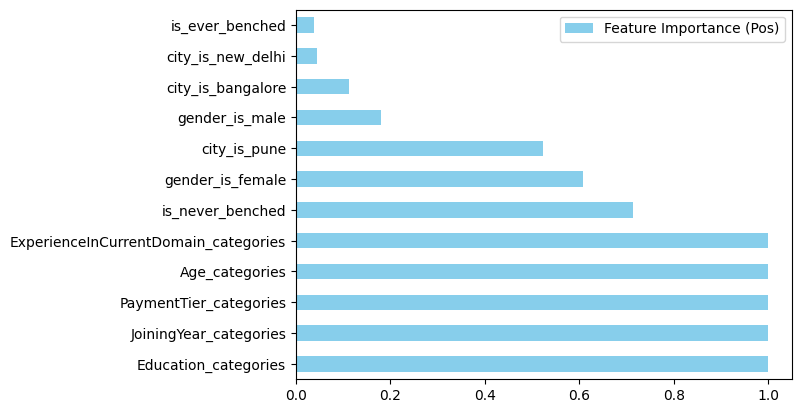

In [ ]:
importance_results['positive'].plot(kind='barh', color='skyblue')

<Axes: >

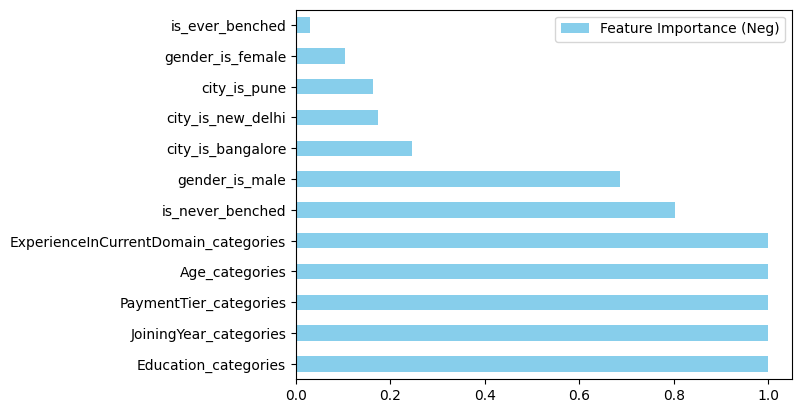

In [75]:
importance_results['negative'].plot(kind='barh', color='skyblue')

# Other classifiers